# One-Class SVM — Hyperparameter Comparison

This notebook follows the same workflow as `one_class_svm.ipynb` but runs the model across **6 hyperparameter configurations** to compare their performance.

**Configurations tested:**

| # | nu | gamma | Rationale |
|---|---|---|---|
| 1 | 0.01 | scale | Very tight boundary — default gamma |
| 2 | 0.05 | scale | Baseline — default settings |
| 3 | 0.10 | scale | Relaxed boundary — default gamma |
| 4 | 0.20 | scale | Loose boundary — default gamma |
| 5 | 0.05 | auto | Baseline nu — broader kernel bandwidth |
| 6 | 0.05 | 0.001 | Baseline nu — very smooth, wide boundary |

**What we are varying:**
- **nu** — controls how tightly the boundary wraps around the normal data. Configs 1–4 isolate this effect with `gamma='scale'` fixed. Smaller nu = tighter fit, fewer allowed training errors.
- **gamma** — controls the shape of the RBF kernel. `'scale'` uses `1 / (n_features × std)`, `'auto'` uses `1 / n_features`, and `0.001` is a manually set small value producing a very smooth, wide boundary. Configs 2, 5, 6 isolate this effect with `nu=0.05` fixed.

**kernel is fixed at `'rbf'`** and **threshold is fixed at the top 5%** of normal training scores across all configurations.

## 1. Hyperparameter Grid

All configurations are defined here. Add or remove entries to experiment with other values.

In [9]:
# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'nu': 0.01, 'gamma': 'scale'},   # very tight boundary
    {'nu': 0.05, 'gamma': 'scale'},   # baseline
    {'nu': 0.10, 'gamma': 'scale'},   # relaxed boundary
    {'nu': 0.20, 'gamma': 'scale'},   # loose boundary
    {'nu': 0.05, 'gamma': 'auto'},    # baseline nu, broader bandwidth
    {'nu': 0.05, 'gamma': 0.001},     # baseline nu, very smooth boundary
]

KERNEL               = 'rbf'  # fixed across all configurations
THRESHOLD_PERCENTILE = 5      # top 5% of normal scores used as the anomaly threshold

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate (kernel={KERNEL!r}, threshold_percentile={THRESHOLD_PERCENTILE}):')
for i, c in enumerate(CONFIGS, 1):
    print(f'  [{i}] nu={c["nu"]:<5}  gamma={str(c["gamma"])}')

6 configurations to evaluate (kernel='rbf', threshold_percentile=5):
  [1] nu=0.01   gamma=scale
  [2] nu=0.05   gamma=scale
  [3] nu=0.1    gamma=scale
  [4] nu=0.2    gamma=scale
  [5] nu=0.05   gamma=auto
  [6] nu=0.05   gamma=0.001


## 2. Imports

Loading all libraries needed for the One-Class SVM model, evaluation metrics, and plotting.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Data

Data is loaded once and reused across all configurations.

- `all_spectra.csv` → **normal** particles (training set)
- `ambient_spectra.csv` → **anomaly** particles (evaluation only)

In [11]:
# Load both datasets
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Separate wavelength features from the polymer label column
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices
X_normal  = all_spectra[wavelengths].values      # (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # (55, 535)

# Ground truth labels: 0 = normal, 1 = anomaly
true_labels = np.concatenate([
    np.zeros(len(X_normal)),
    np.ones(len(X_anomaly))
])

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)


## 4. Run All Configurations

For each configuration, the following steps are performed (identical to `one_class_svm.ipynb`):
1. Train `OneClassSVM` on normal samples only
2. Compute anomaly scores using `decision_function()`, negated so higher = more anomalous
3. Set the decision threshold at the top `THRESHOLD_PERCENTILE` of normal scores
4. Predict labels and compute evaluation metrics

All results are stored in a list for plotting and comparison.

**Note:** One-Class SVM is slower than tree-based models. Each fit may take 10–60 seconds on this dataset.

In [12]:
results = []  # stores output for each configuration

for cfg in CONFIGS:
    nu    = cfg['nu']
    gamma = cfg['gamma']
    label = f"nu={nu}, γ={gamma}"

    # Train One-Class SVM on normal samples only
    oc_svm = OneClassSVM(
        nu=nu,
        kernel=KERNEL,
        gamma=gamma
    )
    oc_svm.fit(X_normal)

    # Negate scores so higher = more anomalous
    scores_normal  = -oc_svm.decision_function(X_normal)
    scores_anomaly = -oc_svm.decision_function(X_anomaly)

    # Set threshold at the top THRESHOLD_PERCENTILE of normal scores
    threshold = np.percentile(scores_normal, 100 - THRESHOLD_PERCENTILE)

    # Combine scores and predict labels
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    # Compute metrics
    roc_auc = roc_auc_score(true_labels, all_scores)
    cm      = confusion_matrix(true_labels, pred_labels)
    fpr, tpr, _ = roc_curve(true_labels, all_scores)

    # Extract TP, TN, FP, FN
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    n_support = oc_svm.support_vectors_.shape[0]

    results.append({
        'label':          label,
        'nu':             nu,
        'gamma':          gamma,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
        'n_support':      n_support,
    })

    print(f'[{label}]  AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}  Support Vectors={n_support}')

print('\nDone.')

[nu=0.01, γ=scale]  AUC=0.944  TP=39  FN=16  FP=61  TN=1154  Recall=0.71  Support Vectors=144
[nu=0.05, γ=scale]  AUC=0.943  TP=39  FN=16  FP=61  TN=1154  Recall=0.71  Support Vectors=145
[nu=0.1, γ=scale]  AUC=0.925  TP=31  FN=24  FP=61  TN=1154  Recall=0.56  Support Vectors=155
[nu=0.2, γ=scale]  AUC=0.883  TP=6  FN=49  FP=61  TN=1154  Recall=0.11  Support Vectors=257
[nu=0.05, γ=auto]  AUC=0.943  TP=39  FN=16  FP=61  TN=1154  Recall=0.71  Support Vectors=145
[nu=0.05, γ=0.001]  AUC=0.947  TP=40  FN=15  FP=61  TN=1154  Recall=0.73  Support Vectors=120

Done.


## 5. Anomaly Score Distributions

One histogram per configuration. Blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model.

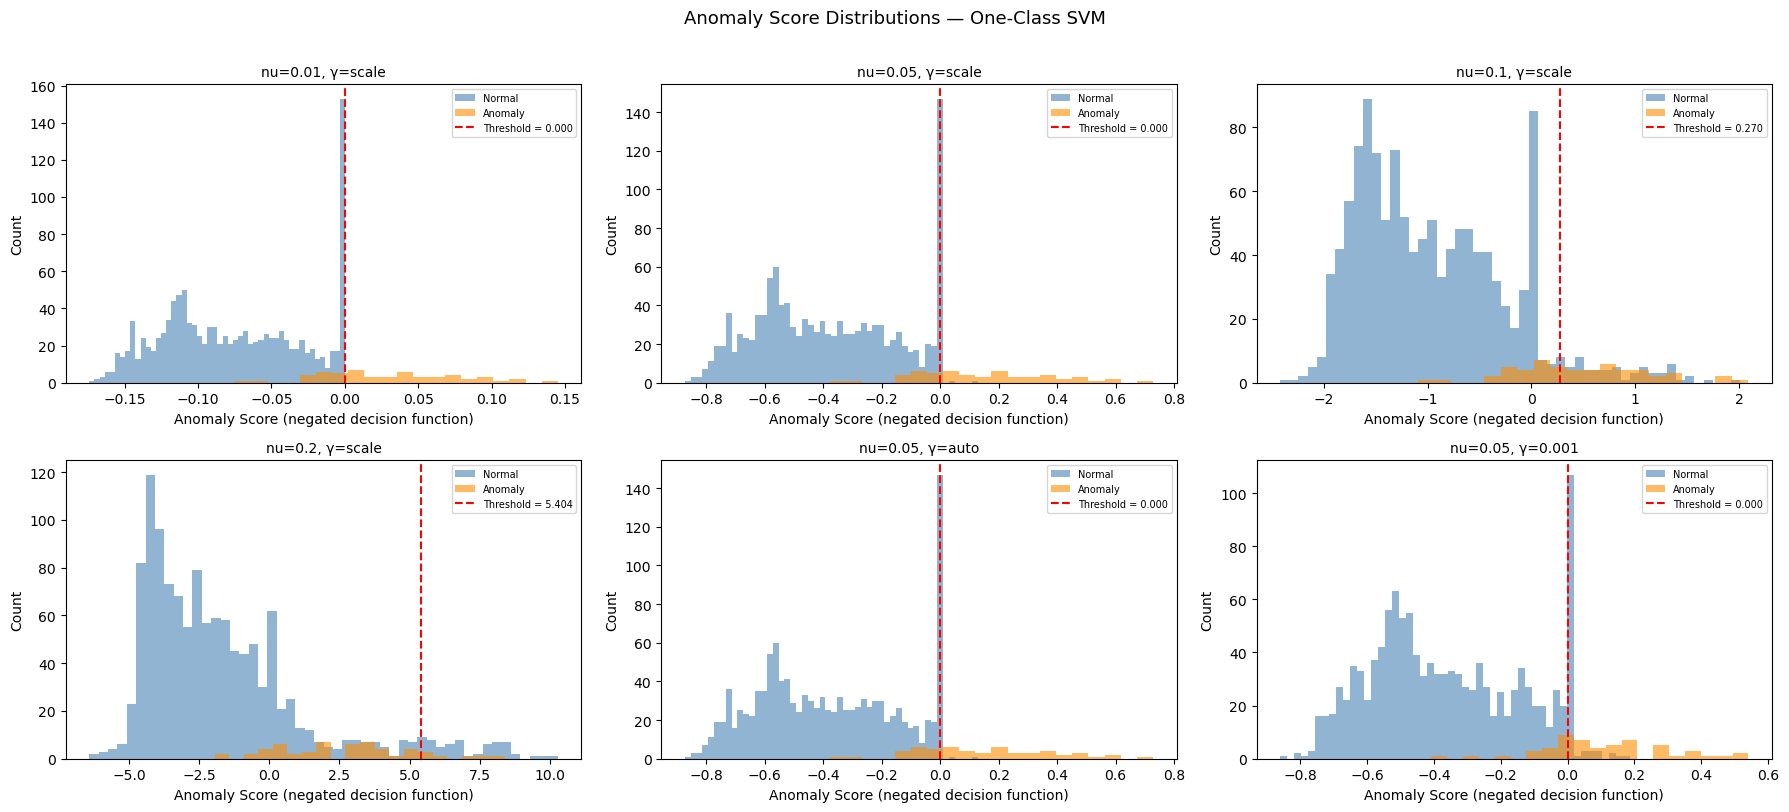

In [13]:
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.3f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (negated decision function)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Anomaly Score Distributions — One-Class SVM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/ocsvm_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

Across all configurations, the normal (blue) distribution is concentrated on the left (lower anomaly scores) and the anomaly (orange) distribution is shifted slightly rightward, but the two classes overlap considerably — reflecting the inherent difficulty of one-class anomaly detection on spectral data.

- **nu=0.01 and nu=0.05 (γ=scale):** Both produce a very compressed score range (≈−0.15 to 0.15 and ≈−0.8 to 0.8, respectively) with the threshold sitting at exactly 0. The normal mass is tightly packed just below the threshold, and anomaly samples cluster near 0 with a small tail above it. The tight scale forces the boundary to lie precisely at the decision surface, making the threshold sensitive to small score differences.

- **nu=0.1 (γ=scale):** The score range widens substantially (≈−2.5 to 2) and the threshold rises to 0.270. The normal distribution becomes bimodal and spread across a wider range, and anomalies are scattered throughout — indicating that the looser boundary is beginning to enclose some anomaly structure, reducing separation.

- **nu=0.2 (γ=scale):** The score range explodes (≈−6 to 10) with the threshold jumping to 5.404. Nearly all anomaly samples fall well below the threshold (scores around −5 to 2), explaining the near-complete recall collapse (Recall = 0.11). The very loose boundary has effectively absorbed most anomalies into the "normal" region.

- **nu=0.05 (γ=auto):** The distribution is nearly identical to nu=0.05 (γ=scale), confirming that for this dataset `auto` and `scale` produce very similar kernel bandwidths and score distributions.

- **nu=0.05 (γ=0.001):** The score range is compact (≈−0.7 to 0.5) and the anomaly tail above the threshold is the most visually distinct of all configurations. The very small gamma creates a very smooth, wide RBF kernel, and the resulting score distribution shows the cleanest separation between the two classes, consistent with its highest AUC (0.947).

## 6. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

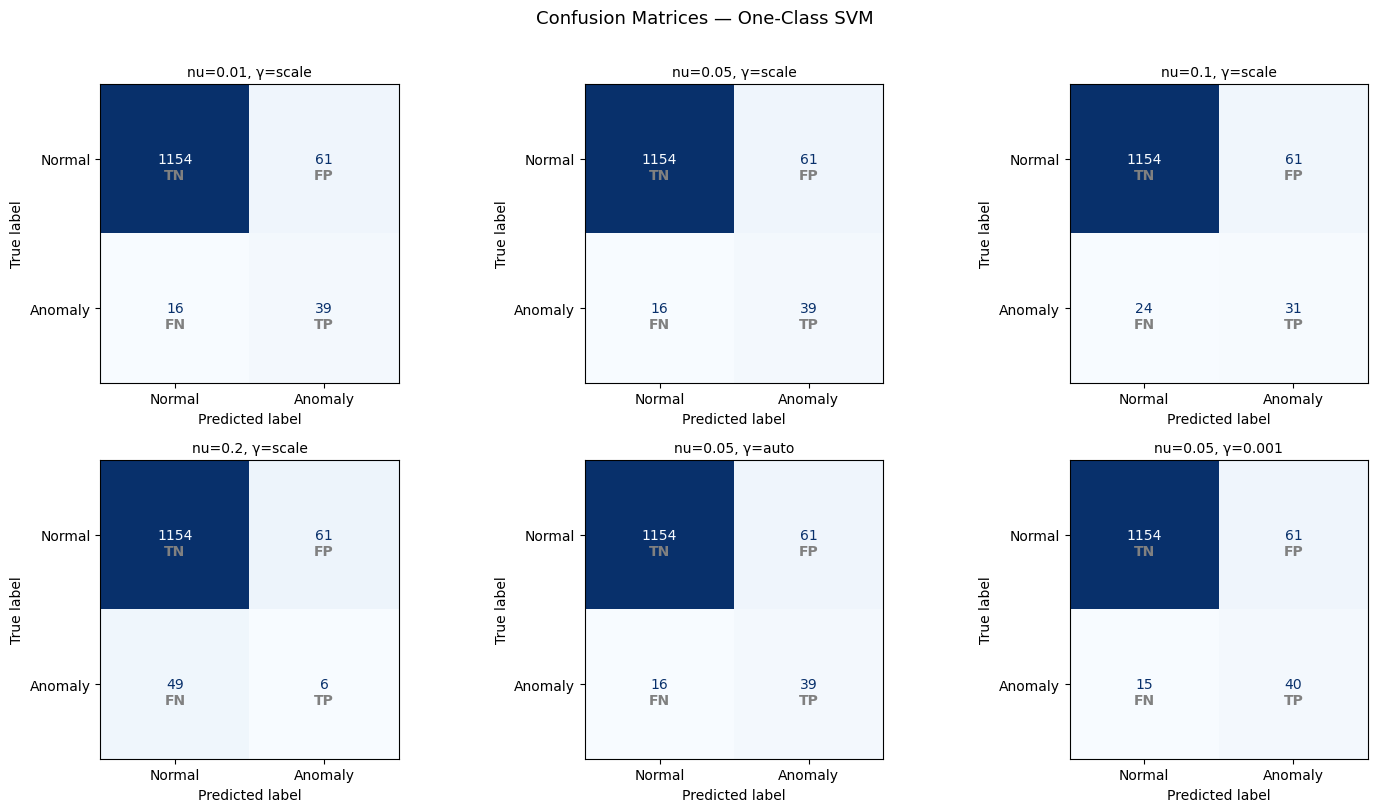

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(r['label'], fontsize=10)

plt.suptitle('Confusion Matrices — One-Class SVM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/ocsvm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

A notable structural pattern appears across all six matrices: the false positive count (FP = 61) is identical in every configuration. This is by design — the threshold is set at the top 5% of normal training scores, so approximately 5% × 1215 ≈ 61 normal samples are always flagged regardless of hyperparameters. The key differentiator between configurations is therefore the true positive count (TP), i.e., how many of the 55 ambient anomalies are detected.

- **nu=0.01 and nu=0.05 (γ=scale), nu=0.05 (γ=auto):** All three produce identical matrices — TP=39, FN=16, Recall=0.71. These configurations are effectively equivalent on this dataset.

- **nu=0.05 (γ=0.001):** The best-performing configuration. TP=40, FN=15, Recall=0.73. A small but meaningful improvement: one additional anomaly is caught compared to the baseline configurations.

- **nu=0.1 (γ=scale):** Performance begins to degrade — TP drops to 31, FN rises to 24, Recall=0.56. Nearly half of all anomalies are missed.

- **nu=0.2 (γ=scale):** A dramatic failure. TP=6, FN=49, Recall=0.11. Only 6 of 55 anomalies are detected, meaning 89% are missed. The very loose boundary (high nu) has enclosed almost all anomaly samples, rendering the model nearly useless for detection at this threshold.

**Takeaway:** Increasing nu beyond 0.05 causes a sharp recall collapse. The FP rate is insensitive to nu because the threshold is percentile-based on normal scores; the model's ability to detect anomalies is entirely governed by the shape of the learned boundary.

## 7. ROC Curves

All 6 ROC curves on one chart for easy comparison. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC has the best threshold-independent separation ability.

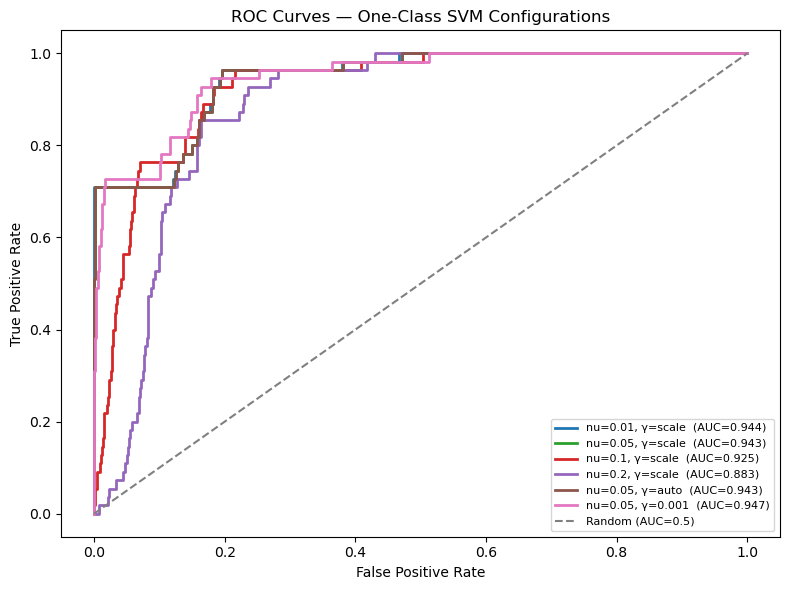

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-Class SVM Configurations')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/ocsvm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All six configurations substantially outperform the random baseline (AUC=0.5), demonstrating that One-Class SVM captures genuine structure in the spectral data. The top four configurations cluster tightly between AUC=0.943 and AUC=0.947, meaning their threshold-independent discrimination ability is nearly identical.

- **nu=0.05, γ=0.001 (AUC=0.947):** The best overall performer. Its ROC curve reaches the highest TPR at low FPR values, confirming the cleaner score separation observed in the distribution plot.

- **nu=0.01 (AUC=0.944), nu=0.05 γ=scale and γ=auto (AUC=0.943):** These three curves are nearly indistinguishable on the plot, confirming the equivalence seen in the confusion matrices.

- **nu=0.1 (AUC=0.925):** A visible step down. The curve rises more slowly at low FPR, indicating reduced ability to catch anomalies without also flagging many normal samples.

- **nu=0.2 (AUC=0.883):** The clear outlier. The curve has a distinctive flat region at low FPR — the model assigns very similar (and mostly low) scores to anomalies and normals, so varying the threshold provides little discriminative gain until the threshold drops far enough to catch everything indiscriminately. This configuration should be avoided.

**Takeaway:** Gamma has a modest positive effect when set to a very small value (0.001), while nu is the dominant hyperparameter. Keeping nu ≤ 0.05 is critical; nu=0.2 degrades the AUC by over 6 points and collapses recall. The ROC analysis confirms that score-based ranking is most informative at low FPR, where nu=0.05, γ=0.001 holds a consistent advantage.

## 8. Summary Table

A single table summarising all key metrics across every configuration, sorted by AUC descending.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), fraction of anomalies detected
- **Precision** — TP / (TP + FP), fraction of flagged samples that are real anomalies
- **Support Vectors** — number of training samples on or near the boundary

In [16]:
summary = pd.DataFrame([{
    'Configuration':   r['label'],
    'nu':              r['nu'],
    'gamma':           str(r['gamma']),
    'Threshold':       round(r['threshold'], 4),
    'AUC':             round(r['roc_auc'], 3),
    'TP':              int(r['tp']),
    'FN':              int(r['fn']),
    'FP':              int(r['fp']),
    'TN':              int(r['tn']),
    'Recall':          round(r['recall'], 3),
    'Precision':       round(r['precision'], 3),
    'Support Vectors': int(r['n_support']),
} for r in results])

summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)
display(summary)

,Configuration,nu,gamma,Threshold,AUC,TP,FN,FP,TN,Recall,Precision,Support Vectors
0,"nu=0.05, γ=0.001",0.05,0.001,0.0000,0.947,40,15,61,1154,0.727,0.396,120
1,"nu=0.01, γ=scale",0.01,scale,0.0000,0.944,39,16,61,1154,0.709,0.390,144
2,"nu=0.05, γ=scale",0.05,scale,0.0001,0.943,39,16,61,1154,0.709,0.390,145
3,"nu=0.05, γ=auto",0.05,auto,0.0001,0.943,39,16,61,1154,0.709,0.390,145
4,"nu=0.1, γ=scale",0.10,scale,0.2699,0.925,31,24,61,1154,0.564,0.337,155
5,"nu=0.2, γ=scale",0.20,scale,5.4044,0.883,6,49,61,1154,0.109,0.090,257


**Results:** *(run the cell and interpret the summary table here)*